# Library

In [13]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
from retinaface import RetinaFace
import cv2
import dlib
import numpy as np
from glob import glob
from matplotlib import pyplot as plt

## Dataset setup

In [14]:
datasets_sample = glob("../all_dataset/FaceShape Dataset/testing_set/Heart/*.jpg")

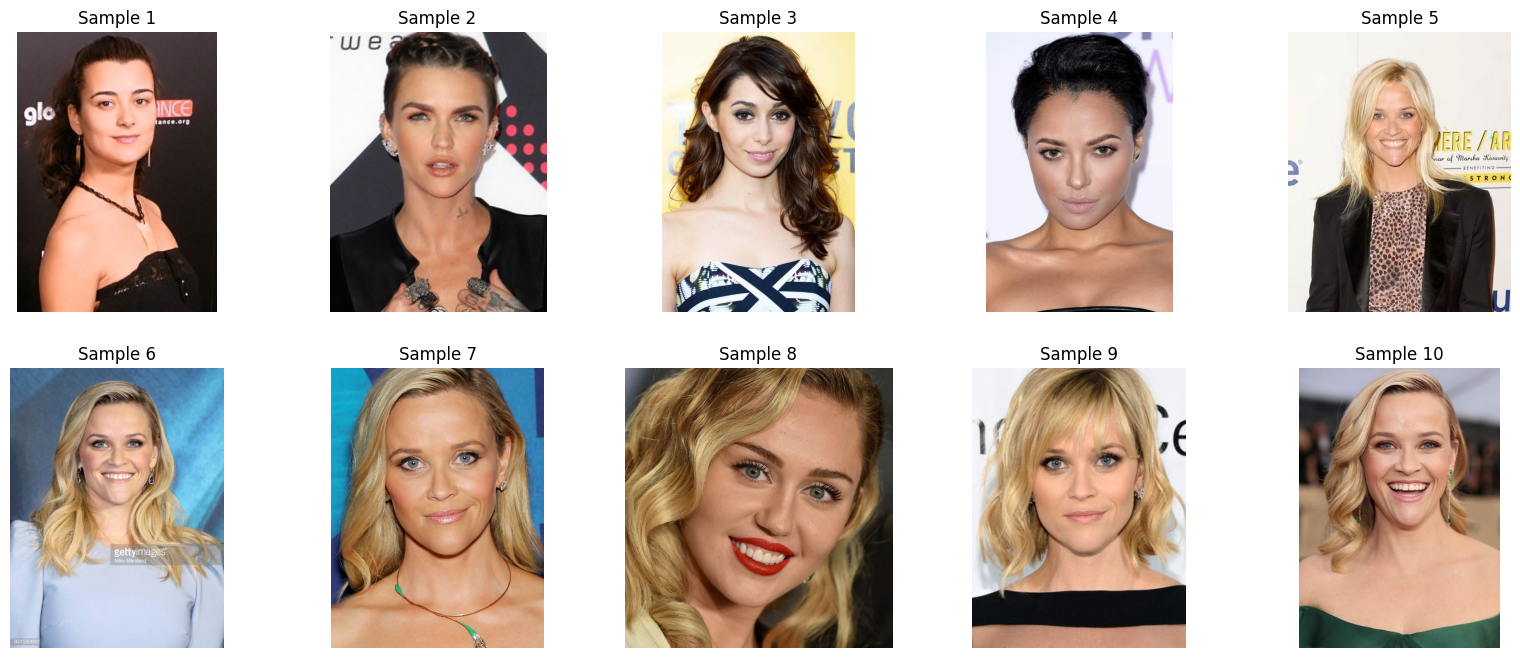

In [15]:
START = 0
if len(datasets_sample) < (START + 10):
    raise ValueError("Not enough samples in the dataset to display.")
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, sample in enumerate(datasets_sample[START:START+10]):
    img = np.array(cv2.imread(sample))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Show image
    plt.subplot(2, 5, i+1)
    plt.axis('off')
    plt.title(f"Sample {START + i + 1}")
    plt.imshow(img_rgb)

## Dlib setup

In [16]:
hog_face_detector = dlib.get_frontal_face_detector()
dlib_facelandmark = dlib.shape_predictor("../models/shape_predictor_68_face_landmarks.dat")

LOWER_FACE_LABELS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16]

## Flow

In [17]:
TEST_ROOT = "../all_dataset/FaceShape Dataset/testing_set"
class_names = sorted([
    d for d in os.listdir(TEST_ROOT)
    if os.path.isdir(os.path.join(TEST_ROOT, d))
])

PAIR_IDX = 0

class_to_images = {}
for cls in class_names:
    patterns = ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]
    files = []
    for p in patterns:
        files.extend(glob(os.path.join(TEST_ROOT, cls, p)))
    class_to_images[cls] = sorted(files)

max_pairs = min((len(v) for v in class_to_images.values()), default=0)
if max_pairs == 0:
    raise ValueError("Tidak ada gambar di testing_set.")
if PAIR_IDX < 0 or PAIR_IDX >= max_pairs:
    raise ValueError(f"PAIR_IDX harus di rentang 0..{max_pairs-1}")

selected_samples = {cls: class_to_images[cls][PAIR_IDX] for cls in class_names}
print("TensorFlow:", tf.__version__)
print("Kelas:", class_names)
print(f"Menampilkan pair index: {PAIR_IDX} dari total {max_pairs} pair")

TensorFlow: 2.21.0
Kelas: ['Heart', 'Oblong', 'Oval', 'Round', 'Square']
Menampilkan pair index: 0 dari total 400 pair


## Retina Face Extraction

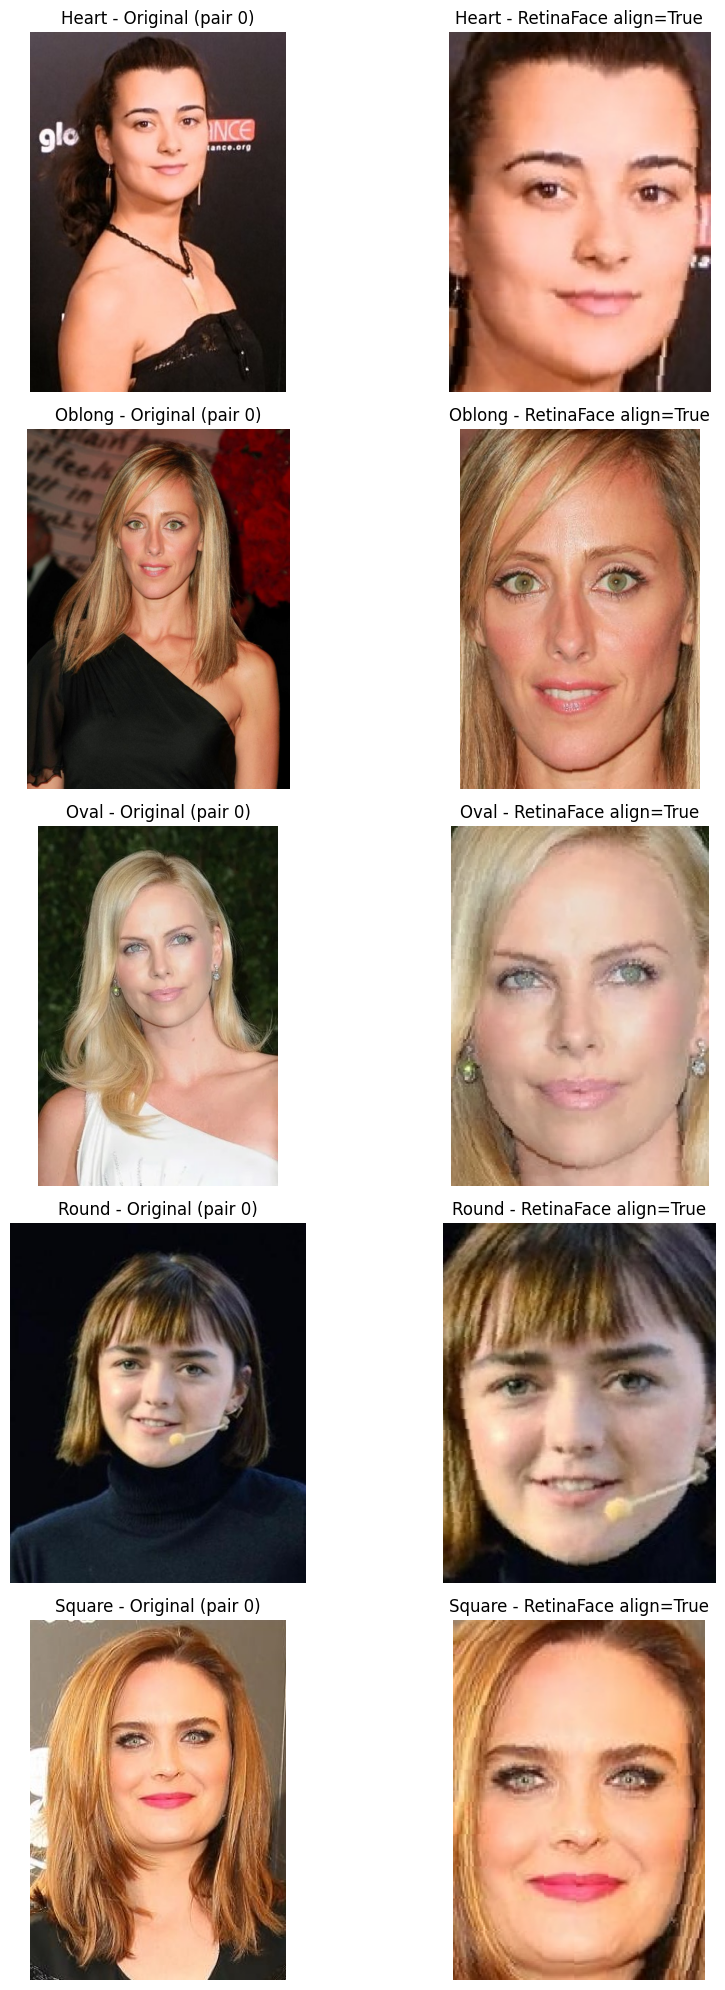

In [18]:
flow_results = {}

for cls in class_names:
    img_path = selected_samples[cls]
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    faces = RetinaFace.extract_faces(img_path=img_path, align=True, expand_face_area=15)
    aligned_face = faces[0] if len(faces) > 0 else None

    flow_results[cls] = {
        "img_path": img_path,
        "original_rgb": img_rgb,
        "aligned_face": aligned_face,
    }

rows = len(class_names)
fig, axes = plt.subplots(rows, 2, figsize=(10, 4 * rows), squeeze=False)

for r, cls in enumerate(class_names):
    axes[r, 0].imshow(flow_results[cls]["original_rgb"])
    axes[r, 0].set_title(f"{cls} - Original (pair {PAIR_IDX})")
    axes[r, 0].axis("off")

    face = flow_results[cls]["aligned_face"]
    if face is not None:
        axes[r, 1].imshow(face)
        axes[r, 1].set_title(f"{cls} - RetinaFace align=True")
    else:
        axes[r, 1].text(0.5, 0.5, "Face not detected", ha="center", va="center")
        axes[r, 1].set_title(f"{cls} - RetinaFace align=True")
    axes[r, 1].axis("off")

plt.tight_layout()
plt.show()

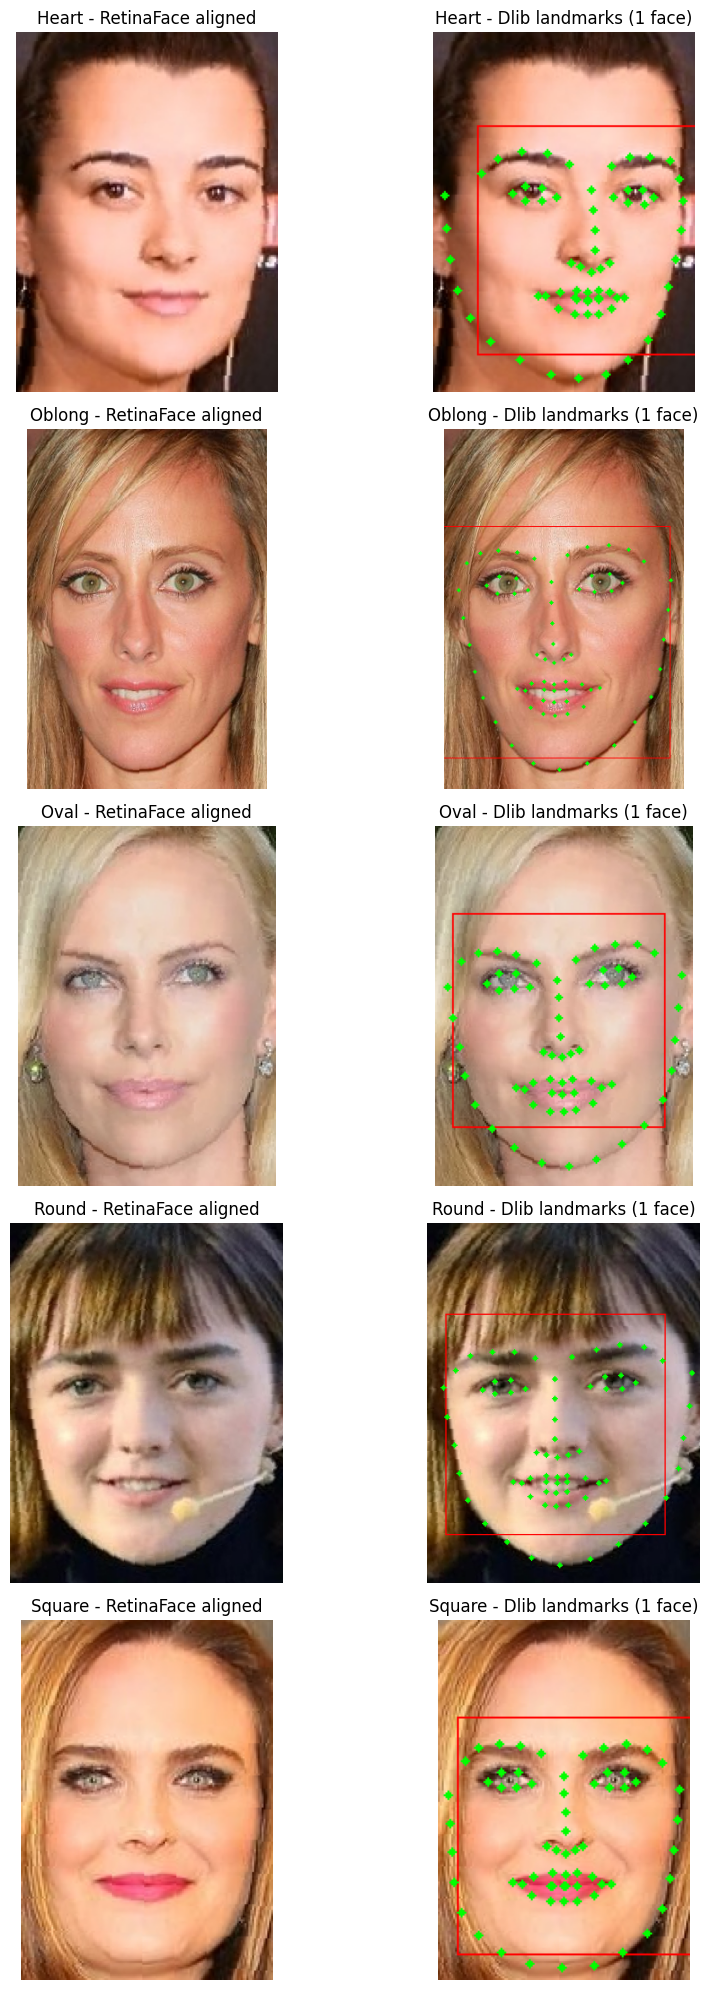

In [19]:
dlib_results = {}

rows = len(class_names)
fig, axes = plt.subplots(rows, 2, figsize=(10, 4 * rows), squeeze=False)

for r, cls in enumerate(class_names):
    aligned_face = flow_results[cls]["aligned_face"]

    if aligned_face is None:
        axes[r, 0].text(0.5, 0.5, "Face not detected", ha="center", va="center")
        axes[r, 0].set_title(f"{cls} - RetinaFace aligned")
        axes[r, 0].axis("off")

        axes[r, 1].text(0.5, 0.5, "No aligned face for Dlib", ha="center", va="center")
        axes[r, 1].set_title(f"{cls} - Dlib landmarks")
        axes[r, 1].axis("off")

        dlib_results[cls] = {
            "num_faces": 0,
            "landmarks": [],
            "annotated_rgb": None,
        }
        continue

    face_rgb = aligned_face.copy()
    if face_rgb.dtype != np.uint8:
        scale = 255.0 if face_rgb.max() <= 1.0 else 1.0
        face_rgb = np.clip(face_rgb * scale, 0, 255).astype(np.uint8)

    if face_rgb.ndim == 2:
        face_rgb = cv2.cvtColor(face_rgb, cv2.COLOR_GRAY2RGB)

    face_bgr = cv2.cvtColor(face_rgb, cv2.COLOR_RGB2BGR)
    gray_img = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2GRAY)
    faces = hog_face_detector(gray_img)

    annotated_rgb = face_rgb.copy()
    cls_landmarks = []

    for face in faces:
        x1, y1 = face.left(), face.top()
        x2, y2 = face.right(), face.bottom()
        cv2.rectangle(annotated_rgb, (x1, y1), (x2, y2), (255, 0, 0), 1)

        landmarks = dlib_facelandmark(gray_img, face)
        pts = []
        for n in range(68):
            x = landmarks.part(n).x
            y = landmarks.part(n).y
            pts.append((x, y))
            cv2.circle(annotated_rgb, (x, y), 2, (0, 255, 0), -1)
        cls_landmarks.append(np.array(pts, dtype=np.int32))

    dlib_results[cls] = {
        "num_faces": len(faces),
        "landmarks": cls_landmarks,
        "annotated_rgb": annotated_rgb,
    }

    axes[r, 0].imshow(face_rgb)
    axes[r, 0].set_title(f"{cls} - RetinaFace aligned")
    axes[r, 0].axis("off")

    if len(faces) > 0:
        axes[r, 1].imshow(annotated_rgb)
        axes[r, 1].set_title(f"{cls} - Dlib landmarks ({len(faces)} face)")
    else:
        axes[r, 1].imshow(face_rgb)
        axes[r, 1].set_title(f"{cls} - Dlib: no face detected")
    axes[r, 1].axis("off")

plt.tight_layout()
plt.show()

## Skin Face Parsing

In [20]:
import importlib
import face_parsing.face_parsing as fp_module

importlib.reload(fp_module)
FaceParsingExtractor = fp_module.FaceParsingExtractor
face_parser = FaceParsingExtractor()

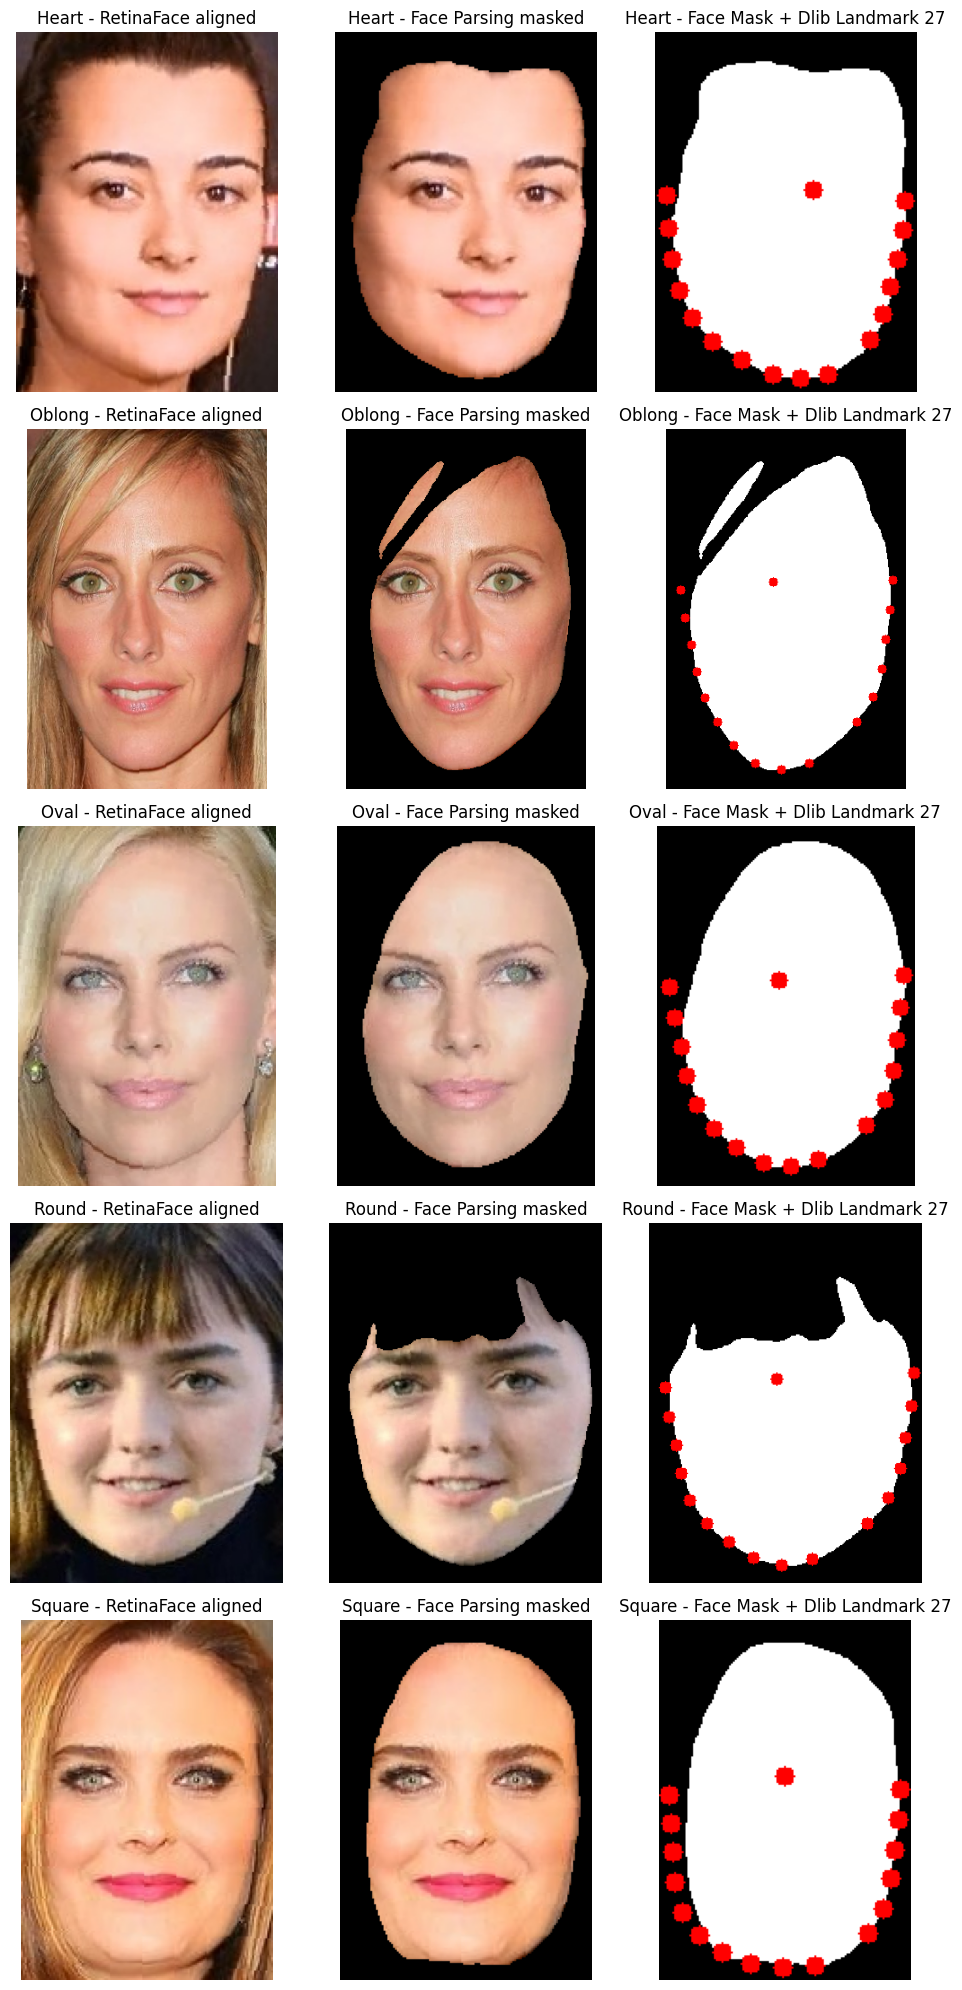

In [21]:
face_parser_results = {}

rows = len(class_names)
fig, axes = plt.subplots(rows, 3, figsize=(10, 4 * rows), squeeze=False)

for i, cls in enumerate(class_names):
    aligned_face = flow_results[cls].get('aligned_face', None)

    if aligned_face is None:
        print('Aligned Face image not extracted')
        continue
    parsing_mask = face_parser.extract(aligned_face)
    face_masked = face_parser.apply_mask(parsing_mask, aligned_face)
    axes[i, 0].imshow(aligned_face)
    axes[i, 0].set_title(f"{cls} - RetinaFace aligned")
    axes[i, 0].axis("off")
    axes[i, 1].imshow(face_masked)
    axes[i, 1].set_title(f"{cls} - Face Parsing masked")
    axes[i, 1].axis("off")
    dlib_landmark_cls = dlib_results[cls]
    if dlib_landmark_cls["num_faces"] > 0:
        x_y_27 = dlib_landmark_cls["landmarks"][0][27]

        # RGB Mask visualization untuk menampilkan titik landmark dengan warna
        mask_vis = parsing_mask.copy()
        if mask_vis.max() <= 1:
            mask_vis = (mask_vis * 255).astype(np.uint8)

        mask_vis = cv2.cvtColor(mask_vis, cv2.COLOR_GRAY2RGB)

        # Gambar Lower face area dengan warna berbeda (misalnya merah)
        for label in LOWER_FACE_LABELS:
            cv2.circle(mask_vis, dlib_landmark_cls["landmarks"][0][label], 5, (255, 0, 0), -1)

        # Gambar titik landmark 27 (merah) lebih besar supaya terlihat
        cv2.circle(mask_vis, (int(x_y_27[0]), int(x_y_27[1])), 5, (255, 0, 0), -1)

        axes[i, 2].set_title(f"{cls} - Face Mask + Dlib Landmark 27")
        axes[i, 2].imshow(mask_vis)
        axes[i, 2].axis("off")
    else:
        axes[i, 2].imshow(cv2.cvtColor(parsing_mask, cv2.COLOR_GRAY2RGB))
        axes[i, 2].set_title(f"{cls} - No Dlib face")
        axes[i, 2].axis("off")

    face_parser_results[cls] = {
        "parsing_mask": parsing_mask,
        "face_masked": face_masked
    }
plt.tight_layout()
plt.show()


# Forehead calculation

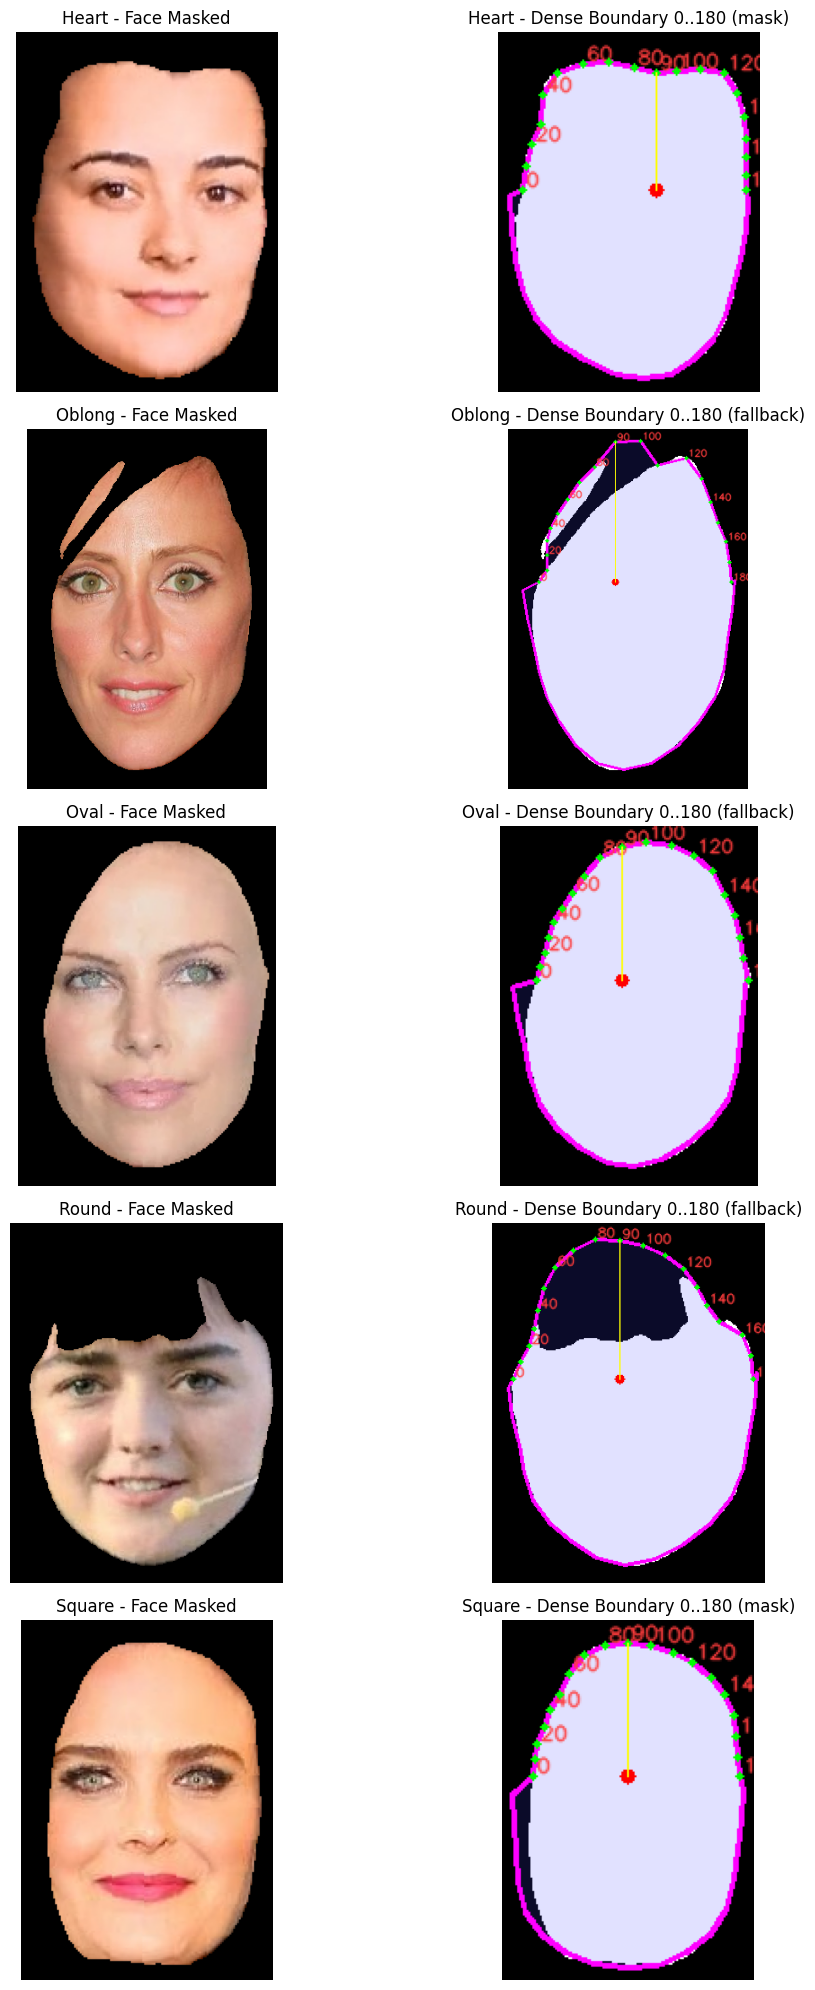

Heart mode= mask raw_valid= 19/19 fallback_ratio= 0.158 angles= (0, 180)
Oblong mode= fallback raw_valid= 19/19 fallback_ratio= 0.526 angles= (0, 180)
Oval mode= fallback raw_valid= 19/19 fallback_ratio= 0.368 angles= (0, 180)
Round mode= fallback raw_valid= 19/19 fallback_ratio= 0.474 angles= (0, 180)
Square mode= mask raw_valid= 19/19 fallback_ratio= 0.0 angles= (0, 180)


In [22]:
def forehead_points_dense(face_mask: np.ndarray,
                                     landmarks: np.ndarray,
                                     angle_start: int = 0,
                                     angle_end: int = 180,
                                     angle_step: int = 10,
                                     return_debug: bool = False):
    """
    Dense forehead boundary ala Cell 17, dengan aturan:
    - Ambil kandidat dari titik putih TERJAUH dari titik 27 pada tiap sudut.
    - Jika kandidat jelek (collision/rambut/putus), fallback berurutan dari tren panjang sudut sebelumnya.
    - Sudut 90 diproses terakhir dan tetap vertikal dari titik 27.
    """
    mask = np.asarray(face_mask)

    if mask.ndim == 3 and mask.shape[2] == 1:
        mask = mask[:, :, 0]
    elif mask.ndim == 3 and mask.shape[2] >= 3:
        mask = cv2.cvtColor(mask, cv2.COLOR_RGB2GRAY)

    if mask.ndim != 2:
        raise ValueError(f"face_mask harus 2D/3D, dapat shape={mask.shape}")

    mask_bin = (mask > 0).astype(np.uint8)
    h, w = mask_bin.shape

    lm = np.asarray(landmarks).reshape(-1, 2).astype(np.float32)
    if lm.shape[0] < 68:
        raise ValueError("landmarks minimal harus 68 titik")

    p0 = lm[0]
    p8 = lm[8]
    p16 = lm[16]
    p17 = lm[17]
    p19 = lm[19]
    p24 = lm[24]
    p26 = lm[26]
    p27 = lm[27]

    center = p27.astype(np.float32)
    center_x = float(center[0])
    center_y = float(center[1])

    def _normalize(v: np.ndarray) -> np.ndarray:
        n = np.linalg.norm(v)
        if n < 1e-8:
            return np.array([0.0, -1.0], dtype=np.float32)
        return (v / n).astype(np.float32)

    def _rotate(v: np.ndarray, deg: float) -> np.ndarray:
        rad = np.deg2rad(deg)
        c, s = np.cos(rad), np.sin(rad)
        return np.array([v[0] * c - v[1] * s, v[0] * s + v[1] * c], dtype=np.float32)

    def _clip_point(pt_xy: np.ndarray) -> tuple[int, int]:
        x = int(np.clip(round(float(pt_xy[0])), 0, w - 1))
        y = int(np.clip(round(float(pt_xy[1])), 0, h - 1))
        return (x, y)

    def _point_at_length(length_val: float, dir_xy: np.ndarray) -> tuple[int, int]:
        pt = center + dir_xy * float(length_val)
        return _clip_point(pt)

    def _ray_segments(dir_xy: np.ndarray):
        max_steps = int(np.hypot(h, w))
        segments = []
        in_run = False
        run_start = 0
        run_len = 0

        for t in range(1, max_steps + 1):
            x = int(round(center[0] + dir_xy[0] * t))
            y = int(round(center[1] + dir_xy[1] * t))

            if x < 0 or x >= w or y < 0 or y >= h:
                if in_run:
                    segments.append((run_start, t - 1, run_len))
                break

            if mask_bin[y, x] > 0:
                if not in_run:
                    in_run = True
                    run_start = t
                    run_len = 1
                else:
                    run_len += 1
            else:
                if in_run:
                    segments.append((run_start, t - 1, run_len))
                    in_run = False
                    run_len = 0

        return segments

    def _farthest_white_hit(dir_xy: np.ndarray):
        segments = _ray_segments(dir_xy)
        if not segments:
            return None
        best = None
        for s, e, run_len in segments:
            score = e + 0.05 * run_len
            if (best is None) or (score > best[0]):
                best = (score, s, e, run_len)
        _, s, e, run_len = best
        return e, _point_at_length(float(e), dir_xy), run_len

    def _snap_near_target(dir_xy: np.ndarray, target_len: float, window: int = 40) -> tuple[int, int]:
        target_len = float(target_len)
        candidates = [target_len]
        for d in range(1, window + 1):
            candidates.extend([target_len + d, target_len - d])

        for L in candidates:
            if L <= 0:
                continue
            x, y = _point_at_length(L, dir_xy)
            if mask_bin[y, x] > 0:
                return (x, y)

        return _point_at_length(target_len, dir_xy)

    angles = list(range(int(angle_start), int(angle_end) + 1, int(angle_step)))
    if 90 not in angles:
        angles.append(90)
    angles = sorted(set([a for a in angles if 0 <= a <= 180]))

    up_vec = np.array([0.0, -1.0], dtype=np.float32)
    dirs = {a: _normalize(_rotate(up_vec, float(a - 90))) for a in angles}

    face_w = float(np.linalg.norm(p16 - p0))
    face_h = float(np.linalg.norm(p8 - p27))

    rx = 0.49 * face_w
    ry = 0.70 * face_h
    ry = float(np.clip(ry, 0.38 * face_w, 1.08 * face_h))
    rx = float(max(rx, 1e-6))
    ry = float(max(ry, 1e-6))

    def _ellipse_len(dir_xy: np.ndarray) -> float:
        dx, dy = float(dir_xy[0]), float(dir_xy[1])
        denom = (dx * dx) / (rx * rx) + (dy * dy) / (ry * ry)
        return float(1.0 / np.sqrt(max(denom, 1e-8)))

    geo_len = {a: _ellipse_len(dirs[a]) for a in angles}

    cap_left = min(
        float(np.linalg.norm(p27 - p0)) * 0.98,
        float(np.linalg.norm(p27 - p17)) + 0.90 * float(np.linalg.norm(p17 - p0)),
    )
    cap_right = min(
        float(np.linalg.norm(p27 - p16)) * 0.98,
        float(np.linalg.norm(p27 - p26)) + 0.90 * float(np.linalg.norm(p26 - p16)),
    )
    cap_mid = 1.22 * face_h

    cap = {}
    for a in angles:
        t = a / 180.0
        cap_lr = (1.0 - t) * cap_left + t * cap_right
        cap_top = cap_mid * np.sin(np.deg2rad(a))
        cap[a] = float(max(0.40 * geo_len[a], min(1.55 * geo_len[a], cap_lr + 0.22 * cap_top)))

    raw_len = {}
    raw_point = {}
    raw_run = {}
    raw_valid = {}

    for a in angles:
        hit = _farthest_white_hit(dirs[a])
        if hit is None:
            raw_len[a] = np.nan
            raw_point[a] = None
            raw_run[a] = 0
            raw_valid[a] = False
            continue

        e, pt, run_len = hit
        raw_len[a] = float(e)
        raw_point[a] = pt
        raw_run[a] = int(run_len)

        raw_valid[a] = bool(
            (raw_len[a] >= 0.20 * geo_len[a])
            and (raw_len[a] <= 1.95 * geo_len[a])
            and (raw_run[a] >= 2)
        )

    final_len = {}
    source = {}

    left_angles = sorted([a for a in angles if a < 90])
    right_angles = sorted([a for a in angles if a > 90], reverse=True)

    def _predict_len(a: int, prev_len: float | None, prev_prev_len: float | None) -> float:
        g = geo_len[a]
        if prev_len is None:
            return float(g)
        if prev_prev_len is None:
            return float(0.70 * prev_len + 0.30 * g)
        slope = float(np.clip(prev_len - prev_prev_len, -0.18 * face_w, 0.24 * face_w))
        pred = prev_len + slope
        return float(0.75 * pred + 0.25 * g)

    def _sweep(side_angles, side_name: str):
        prev_len = None
        prev_prev_len = None
        prev_y = None

        for a in side_angles:
            pred = _predict_len(a, prev_len, prev_prev_len)
            g = geo_len[a]

            if raw_valid[a]:
                cand = float(raw_len[a])
                src = "mask-farthest"
            else:
                cand = float(pred)
                src = "fallback-none"

            band_low = max(0.11 * face_w, 0.22 * g)
            band_high = max(0.12 * face_w, 0.26 * g)
            min_allow = max(0.55 * g, pred - band_low)
            max_allow = min(1.55 * g, pred + band_high)

            if prev_len is not None:
                ratio_floor = 0.84
                if abs(a - 90) <= 50:
                    ratio_floor = 0.88
                min_allow = max(min_allow, prev_len * ratio_floor)
                max_allow = min(max_allow, prev_len * 1.22 + 0.08 * face_w)

            if (cand < min_allow) or (cand > max_allow):
                cand = float(np.clip(pred, min_allow, max_allow))
                src = "fallback-trend"

            if raw_valid[a] and raw_run[a] <= 2 and src.startswith("mask"):
                cand = float(np.clip(0.60 * cand + 0.40 * pred, min_allow, max_allow))
                src = "fallback-collision"

            probe = _point_at_length(cand, dirs[a])
            if prev_y is not None:
                y_drop_limit = max(6.0, 0.08 * face_h)
                if probe[1] > prev_y + y_drop_limit:
                    dy = float(dirs[a][1])
                    target_y = prev_y + y_drop_limit
                    if dy < -1e-6:
                        len_needed = (target_y - center_y) / dy
                        cand = max(cand, float(len_needed))
                    cand = float(np.clip(cand, min_allow, max_allow))
                    probe = _point_at_length(cand, dirs[a])
                    src = "fallback-y"

            if side_name == "left" and probe[0] > center_x + 2:
                cand = float(np.clip(pred, min_allow, max_allow))
                probe = _point_at_length(cand, dirs[a])
                src = "fallback-side"
            if side_name == "right" and probe[0] < center_x - 2:
                cand = float(np.clip(pred, min_allow, max_allow))
                probe = _point_at_length(cand, dirs[a])
                src = "fallback-side"

            final_len[a] = cand
            source[a] = src
            prev_prev_len = prev_len
            prev_len = cand
            prev_y = float(probe[1])

    _sweep(left_angles, "left")
    _sweep(right_angles, "right")

    if 90 in angles:
        neighbor_vals = []
        if 80 in final_len:
            neighbor_vals.append(final_len[80])
        if 100 in final_len:
            neighbor_vals.append(final_len[100])
        if not neighbor_vals:
            if left_angles:
                neighbor_vals.append(final_len[left_angles[-1]])
            if right_angles:
                neighbor_vals.append(final_len[right_angles[-1]])

        neighbor_ref = max(neighbor_vals) if neighbor_vals else geo_len[90]
        pred90 = float(max(0.98 * neighbor_ref, geo_len[90]))

        if raw_valid.get(90, False) and raw_run.get(90, 0) >= 3:
            cand90 = float(raw_len[90])
            src90 = "mask-farthest"
        else:
            cand90 = pred90
            src90 = "fallback-none"

        min90 = max(0.72 * neighbor_ref, 0.45 * geo_len[90])
        max90 = min(1.18 * neighbor_ref + 0.05 * face_w, 1.45 * geo_len[90], cap[90])

        if (cand90 < min90) or (cand90 > max90):
            cand90 = float(np.clip(pred90, min90, max90))
            src90 = "fallback-trend"

        if len(neighbor_vals) >= 2:
            neigh_mean = float(np.mean(neighbor_vals))
            clipped = float(np.clip(cand90, 0.92 * neigh_mean, 1.08 * neigh_mean))
            if abs(clipped - cand90) > 1e-6:
                cand90 = clipped
                src90 = "fallback-center"

        final_len[90] = cand90
        source[90] = src90

    # Global anti-spike smoothing di domain panjang sudut.
    for _ in range(2):
        for i in range(1, len(angles)):
            a0 = angles[i - 1]
            a1 = angles[i]
            max_delta = max(0.16 * face_w, 0.34 * geo_len[a1])
            upper = final_len[a0] + max_delta
            lower = final_len[a0] - max_delta
            old = final_len[a1]
            final_len[a1] = float(np.clip(final_len[a1], lower, upper))
            if abs(final_len[a1] - old) > 1e-6:
                source[a1] = "fallback-smooth"

        for i in range(len(angles) - 2, -1, -1):
            a0 = angles[i + 1]
            a1 = angles[i]
            max_delta = max(0.16 * face_w, 0.34 * geo_len[a1])
            upper = final_len[a0] + max_delta
            lower = final_len[a0] - max_delta
            old = final_len[a1]
            final_len[a1] = float(np.clip(final_len[a1], lower, upper))
            if abs(final_len[a1] - old) > 1e-6:
                source[a1] = "fallback-smooth"

    # Center-band clamp untuk meredam notch/spike sekitar 90..120.
    center_band = [a for a in angles if 70 <= a <= 120]
    for _ in range(2):
        for i in range(1, len(center_band)):
            a0 = center_band[i - 1]
            a1 = center_band[i]
            max_delta = max(0.10 * face_w, 0.18 * geo_len[a1])
            old = final_len[a1]
            final_len[a1] = float(np.clip(final_len[a1], final_len[a0] - max_delta, final_len[a0] + max_delta))
            if abs(final_len[a1] - old) > 1e-6:
                source[a1] = "fallback-center"

        for i in range(len(center_band) - 2, -1, -1):
            a0 = center_band[i + 1]
            a1 = center_band[i]
            max_delta = max(0.10 * face_w, 0.18 * geo_len[a1])
            old = final_len[a1]
            final_len[a1] = float(np.clip(final_len[a1], final_len[a0] - max_delta, final_len[a0] + max_delta))
            if abs(final_len[a1] - old) > 1e-6:
                source[a1] = "fallback-center"

    for i in range(1, len(angles) - 1):
        a_prev = angles[i - 1]
        a = angles[i]
        a_next = angles[i + 1]
        if a == 90:
            continue
        med = float(np.median([final_len[a_prev], final_len[a], final_len[a_next]]))
        tol = max(0.12 * face_w, 0.20 * geo_len[a])
        if abs(final_len[a] - med) > tol:
            final_len[a] = float(0.65 * final_len[a] + 0.35 * med)
            source[a] = "fallback-smooth"

    angle_points = {}
    for a in angles:
        use_raw = (
            source.get(a, "") == "mask-farthest"
            and raw_point[a] is not None
            and np.isfinite(raw_len[a])
            and abs(raw_len[a] - final_len[a]) <= 0.09 * geo_len[a]
        )
        if use_raw:
            angle_points[a] = raw_point[a]
        else:
            angle_points[a] = _snap_near_target(dirs[a], final_len[a], window=40)
            if source.get(a, "").startswith("mask"):
                source[a] = "fallback-trend"

    def _radius_floor(side_angles):
        prev_r = None
        for a in side_angles:
            pt = np.array(angle_points[a], dtype=np.float32)
            r = float(np.linalg.norm(pt - center))
            if prev_r is not None:
                floor_r = prev_r * (0.88 if abs(a - 90) <= 50 else 0.84)
                if r < floor_r:
                    cand = max(final_len[a], floor_r)
                    cand = float(np.clip(cand, 0.55 * geo_len[a], min(1.55 * geo_len[a], cap[a])))
                    angle_points[a] = _snap_near_target(dirs[a], cand, window=44)
                    final_len[a] = cand
                    source[a] = "fallback-trend"
                    pt = np.array(angle_points[a], dtype=np.float32)
                    r = float(np.linalg.norm(pt - center))
            prev_r = r

    _radius_floor(left_angles)
    _radius_floor(right_angles)

    for a in left_angles:
        x, y = angle_points[a]
        x = min(x, int(np.floor(center_x)) - 1)
        angle_points[a] = (int(np.clip(x, 0, w - 1)), y)

    right_sorted = sorted([a for a in angles if a > 90])

    if left_angles:
        last_x = -10**9
        for a in left_angles:
            x, y = angle_points[a]
            if x < last_x:
                x = last_x
            angle_points[a] = (int(np.clip(x, 0, w - 1)), y)
            last_x = x

    if right_sorted:
        last_x = int(np.ceil(center_x)) + 1
        for a in right_sorted:
            x, y = angle_points[a]
            x = max(x, int(np.ceil(center_x)) + 1)
            if x < last_x:
                x = last_x
            angle_points[a] = (int(np.clip(x, 0, w - 1)), y)
            last_x = x

    if 90 in angle_points:
        p90 = _snap_near_target(dirs[90], final_len[90], window=48)
        angle_points[90] = (int(np.clip(round(center_x), 0, w - 1)), int(np.clip(p90[1], 0, h - 1)))

    fallback_ratio = float(sum(1 for a in angles if str(source.get(a, "")).startswith("fallback")) / max(len(angles), 1))
    mode = "fallback" if fallback_ratio >= 0.30 else "mask"

    debug = {
        "mode": mode,
        "fallback_ratio": fallback_ratio,
        "raw_valid_count": int(sum(1 for a in angles if raw_valid[a])),
        "raw_len": raw_len,
        "raw_run": raw_run,
        "geo_len": geo_len,
        "final_len": final_len,
        "cap": cap,
        "angles": angles,
        "source": source,
    }

    if return_debug:
        return angle_points, debug
    return angle_points


def build_face_boundary_dense(landmarks: np.ndarray, angle_points: dict) -> list:
    lm = np.asarray(landmarks).reshape(-1, 2).astype(np.int32)
    jaw = [tuple(map(int, lm[i])) for i in range(17)]
    top_angles = sorted(angle_points.keys(), reverse=True)
    top_chain = [tuple(map(int, angle_points[a])) for a in top_angles]
    return jaw + top_chain + [jaw[0]]


ANGLES_DENSE = list(range(0, 181, 10))

dense_results = {}
rows = len(class_names)
fig, axes = plt.subplots(rows, 2, figsize=(12, 4 * rows), squeeze=False)

for i, cls in enumerate(class_names):
    parsing_info = face_parser_results.get(cls, {})
    parsing_mask = parsing_info.get("parsing_mask", None)
    masked_face = parsing_info.get("face_masked", None)
    dlib_info = dlib_results.get(cls, {})

    if parsing_mask is None or dlib_info.get("num_faces", 0) <= 0:
        axes[i, 0].text(0.5, 0.5, "Data parsing/dlib belum tersedia", ha="center", va="center")
        axes[i, 0].set_title(f"{cls} - Input")
        axes[i, 0].axis("off")

        axes[i, 1].text(0.5, 0.5, "Lewati dense angle", ha="center", va="center")
        axes[i, 1].set_title(f"{cls} - Dense 0..180")
        axes[i, 1].axis("off")
        continue

    landmarks = np.asarray(dlib_info["landmarks"][0], dtype=np.int32)
    angle_points, dbg = forehead_points_dense(
        parsing_mask,
        landmarks,
        angle_start=ANGLES_DENSE[0],
        angle_end=ANGLES_DENSE[-1],
        angle_step=10,
        return_debug=True,
    )
    boundary_points = build_face_boundary_dense(landmarks, angle_points)

    if parsing_mask.ndim == 2:
        vis = cv2.cvtColor(parsing_mask.astype(np.uint8), cv2.COLOR_GRAY2RGB)
    elif parsing_mask.ndim == 3 and parsing_mask.shape[2] == 1:
        vis = cv2.cvtColor(parsing_mask[:, :, 0].astype(np.uint8), cv2.COLOR_GRAY2RGB)
    else:
        vis = parsing_mask.copy().astype(np.uint8)

    if vis.max() <= 1:
        vis = (vis * 255).astype(np.uint8)

    overlay = vis.copy()
    cv2.fillPoly(overlay, [np.array(boundary_points, dtype=np.int32)], (70, 70, 255))
    vis = cv2.addWeighted(overlay, 0.16, vis, 0.84, 0)

    # Jawline 0..16
    jaw_pts = [tuple(map(int, landmarks[idx])) for idx in range(17)]
    for j in range(16):
        cv2.line(vis, jaw_pts[j], jaw_pts[j + 1], (0, 220, 255), 1)

    # Top chain dense (180 -> ... -> 0)
    top_angles_desc = sorted(angle_points.keys(), reverse=True)
    top_chain = [angle_points[a] for a in top_angles_desc]
    for j in range(len(top_chain) - 1):
        cv2.line(vis, top_chain[j], top_chain[j + 1], (0, 255, 0), 1)

    if 180 in angle_points:
        cv2.line(vis, jaw_pts[16], angle_points[180], (255, 0, 255), 2)
    if 0 in angle_points:
        cv2.line(vis, angle_points[0], jaw_pts[0], (255, 0, 255), 2)
    cv2.polylines(vis, [np.array(boundary_points, dtype=np.int32)], True, (255, 0, 255), 2)

    for a in sorted(angle_points.keys()):
        pt = tuple(map(int, angle_points[a]))
        cv2.circle(vis, pt, 2, (0, 255, 0), -1)
        if a % 20 == 0 or a == 90:
            cv2.putText(vis, str(a), (pt[0] + 2, pt[1] - 2), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (255, 60, 60), 1, cv2.LINE_AA)

    p27 = tuple(map(int, landmarks[27]))
    if 90 in angle_points:
        cv2.circle(vis, p27, 4, (255, 0, 0), -1)
        cv2.line(vis, p27, tuple(map(int, angle_points[90])), (255, 255, 0), 1)

    if masked_face is not None:
        axes[i, 0].imshow(masked_face)
    else:
        aligned_face = flow_results[cls].get("aligned_face", None)
        if aligned_face is not None:
            axes[i, 0].imshow(aligned_face)
        else:
            axes[i, 0].imshow(np.zeros((vis.shape[0], vis.shape[1], 3), dtype=np.uint8))
    axes[i, 0].set_title(f"{cls} - Face Masked")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(vis)
    axes[i, 1].set_title(f"{cls} - Dense Boundary 0..180 ({dbg['mode']})")
    axes[i, 1].axis("off")

    dense_results[cls] = {
        "angle_points": angle_points,
        "boundary_points": boundary_points,
        "debug": dbg,
    }

plt.tight_layout()
plt.show()

for cls in class_names:
    if cls in dense_results:
        dbg = dense_results[cls]["debug"]
        print(
            cls,
            "mode=", dbg["mode"],
            "raw_valid=", f"{dbg['raw_valid_count']}/{len(dbg['angles'])}",
            "fallback_ratio=", round(dbg["fallback_ratio"], 3),
            "angles=", (min(dbg["angles"]), max(dbg["angles"])),
        )

## Extract Some Features From Current State Dlib And Forehead Calculation

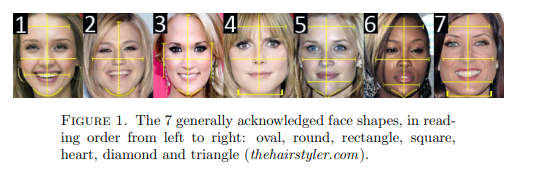

Test class: Heart
Test image: ../all_dataset/FaceShape Dataset/testing_set\Heart\heart (101).jpg


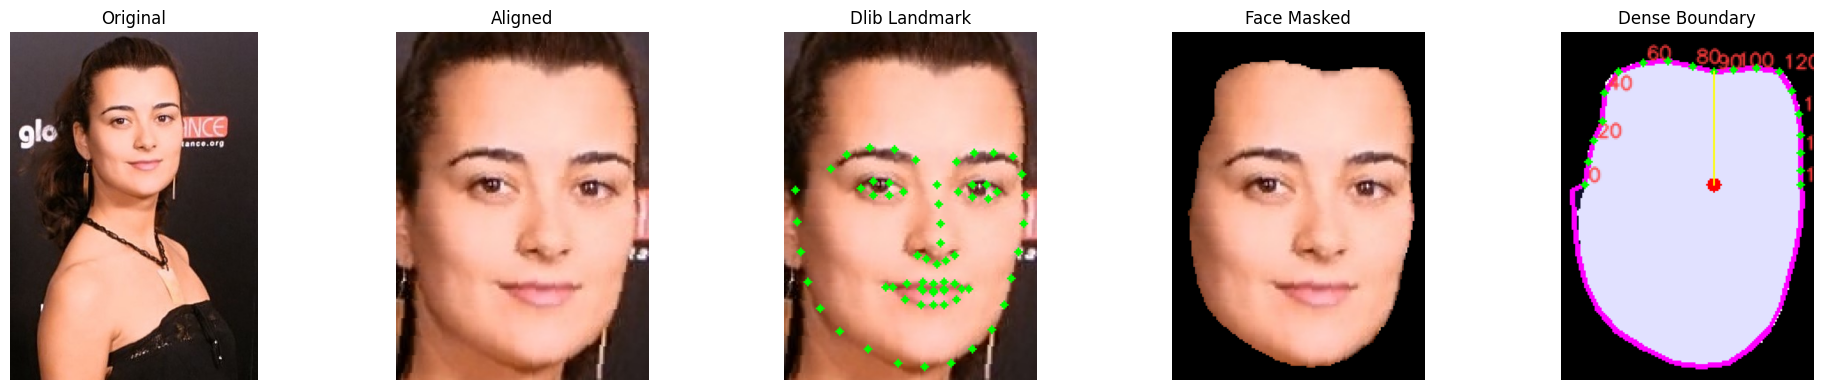

In [23]:
# Single image extraction test (end-to-end)
TEST_CLASS = "Heart" if "Heart" in class_to_images else class_names[0]
TEST_IMAGE_IDX = 0

if TEST_CLASS not in class_to_images:
    raise ValueError(f"Kelas {TEST_CLASS} tidak ditemukan di class_to_images")
if len(class_to_images[TEST_CLASS]) == 0:
    raise ValueError(f"Kelas {TEST_CLASS} tidak punya gambar")
if TEST_IMAGE_IDX < 0 or TEST_IMAGE_IDX >= len(class_to_images[TEST_CLASS]):
    raise ValueError(f"TEST_IMAGE_IDX harus di rentang 0..{len(class_to_images[TEST_CLASS]) - 1}")

test_class = TEST_CLASS
test_img_path = class_to_images[test_class][TEST_IMAGE_IDX]

test_img_bgr = cv2.imread(test_img_path)
if test_img_bgr is None:
    raise ValueError(f"Gagal membaca gambar: {test_img_path}")

test_picture = cv2.cvtColor(test_img_bgr, cv2.COLOR_BGR2RGB)

# 1) RetinaFace align
faces = RetinaFace.extract_faces(img_path=test_img_path, align=True, expand_face_area=15)
test_aligned_face = faces[0] if len(faces) > 0 else None
if test_aligned_face is None:
    raise ValueError("RetinaFace tidak mendeteksi wajah pada gambar ini")

if test_aligned_face.dtype != np.uint8:
    scale = 255.0 if test_aligned_face.max() <= 1.0 else 1.0
    test_aligned_face = np.clip(test_aligned_face * scale, 0, 255).astype(np.uint8)
if test_aligned_face.ndim == 2:
    test_aligned_face = cv2.cvtColor(test_aligned_face, cv2.COLOR_GRAY2RGB)

# 2) Dlib landmark
face_bgr = cv2.cvtColor(test_aligned_face, cv2.COLOR_RGB2BGR)
test_gray = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2GRAY)
test_faces = hog_face_detector(test_gray)
if len(test_faces) == 0:
    raise ValueError("Dlib tidak mendeteksi wajah pada aligned face")

test_landmark_shape = dlib_facelandmark(test_gray, test_faces[0])
test_landmarks = np.array(
    [(test_landmark_shape.part(i).x, test_landmark_shape.part(i).y) for i in range(68)],
    dtype=np.int32,
)
test_landmark = test_landmarks

test_landmark_vis = test_aligned_face.copy()
for x, y in test_landmarks:
    cv2.circle(test_landmark_vis, (int(x), int(y)), 2, (0, 255, 0), -1)

# 3) Face parsing mask
test_parsing_mask = face_parser.extract(test_aligned_face)
test_face_masked = face_parser.apply_mask(test_parsing_mask, test_aligned_face)

# 4) Forehead dense angle + boundary
test_angle_points, test_debug = forehead_points_dense(
    test_parsing_mask,
    test_landmarks,
    angle_start=0,
    angle_end=180,
    angle_step=10,
    return_debug=True,
)
test_boundary_points = build_face_boundary_dense(test_landmarks, test_angle_points)

if test_parsing_mask.ndim == 2:
    test_boundary_vis = cv2.cvtColor(test_parsing_mask.astype(np.uint8), cv2.COLOR_GRAY2RGB)
elif test_parsing_mask.ndim == 3 and test_parsing_mask.shape[2] == 1:
    test_boundary_vis = cv2.cvtColor(test_parsing_mask[:, :, 0].astype(np.uint8), cv2.COLOR_GRAY2RGB)
else:
    test_boundary_vis = test_parsing_mask.copy().astype(np.uint8)

if test_boundary_vis.max() <= 1:
    test_boundary_vis = (test_boundary_vis * 255).astype(np.uint8)

overlay = test_boundary_vis.copy()
cv2.fillPoly(overlay, [np.array(test_boundary_points, dtype=np.int32)], (70, 70, 255))
test_boundary_vis = cv2.addWeighted(overlay, 0.16, test_boundary_vis, 0.84, 0)

jaw_pts = [tuple(map(int, test_landmarks[idx])) for idx in range(17)]
for j in range(16):
    cv2.line(test_boundary_vis, jaw_pts[j], jaw_pts[j + 1], (0, 220, 255), 1)

top_angles_desc = sorted(test_angle_points.keys(), reverse=True)
top_chain = [test_angle_points[a] for a in top_angles_desc]
for j in range(len(top_chain) - 1):
    cv2.line(test_boundary_vis, top_chain[j], top_chain[j + 1], (0, 255, 0), 1)

if 180 in test_angle_points:
    cv2.line(test_boundary_vis, jaw_pts[16], test_angle_points[180], (255, 0, 255), 2)
if 0 in test_angle_points:
    cv2.line(test_boundary_vis, test_angle_points[0], jaw_pts[0], (255, 0, 255), 2)
cv2.polylines(test_boundary_vis, [np.array(test_boundary_points, dtype=np.int32)], True, (255, 0, 255), 2)

for a in sorted(test_angle_points.keys()):
    pt = tuple(map(int, test_angle_points[a]))
    cv2.circle(test_boundary_vis, pt, 2, (0, 255, 0), -1)
    if a % 20 == 0 or a == 90:
        cv2.putText(
            test_boundary_vis,
            str(a),
            (pt[0] + 2, pt[1] - 2),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.35,
            (255, 60, 60),
            1,
            cv2.LINE_AA,
        )

if 90 in test_angle_points:
    p27 = tuple(map(int, test_landmarks[27]))
    cv2.circle(test_boundary_vis, p27, 4, (255, 0, 0), -1)
    cv2.line(test_boundary_vis, p27, tuple(map(int, test_angle_points[90])), (255, 255, 0), 1)

# Bundle semua output penting dalam satu variabel
test_extraction = {
    "class_name": test_class,
    "image_index": TEST_IMAGE_IDX,
    "img_path": test_img_path,
    "original_rgb": test_picture,
    "aligned_face": test_aligned_face,
    "landmarks": test_landmarks,
    "landmark_vis": test_landmark_vis,
    "parsing_mask": test_parsing_mask,
    "face_masked": test_face_masked,
    "angle_points": test_angle_points,
    "boundary_points": test_boundary_points,
    "dense_debug": test_debug,
    "boundary_vis": test_boundary_vis,
}

print(f"Test class: {test_class}")
print(f"Test image: {test_img_path}")

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes[0].imshow(test_picture)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(test_aligned_face)
axes[1].set_title("Aligned")
axes[1].axis("off")

axes[2].imshow(test_landmark_vis)
axes[2].set_title("Dlib Landmark")
axes[2].axis("off")

axes[3].imshow(test_face_masked)
axes[3].set_title("Face Masked")
axes[3].axis("off")

axes[4].imshow(test_boundary_vis)
axes[4].set_title("Dense Boundary")
axes[4].axis("off")

plt.tight_layout()
plt.show()

### Test Extraction
- Face height
- Face width
- Forehead height
- Forehead width
- Jaw width
- Chin Width
- Chin Angle
- Skeleton Angle (Left, Right)
- Jidat Angle

### Metrics untuk Heart Experimental
- dahi_70
- dahi_110
- y_90_normalized
- y_max_normalized

In [24]:
## Picture shape
pic_height, pic_width = test_extraction["face_masked"].shape[:2]
print(f"Picture shape: {pic_width}x{pic_height}")
max_dim = max(pic_width, pic_height)
print(f"Max dimension: {max_dim}")

## Max Dimension untuk ukuran relatif

## Face Height relative dari gambar diambil dari garis yang ditarik lurus dari titik 8 - titik 90 derajat.
p8 = test_extraction["landmarks"][8]
p90 = test_extraction["angle_points"][90]
face_height_px = np.linalg.norm(np.array(p8) - np.array(p90))
face_height = face_height_px / max_dim
print(f"Relative face height (landmark 8 to point 90): {face_height:.3f}")

## Face width relative dari gambar diambil dari garis yang ditarik lurus dari titik landmark 1 - landmark 29 - landmark 15
p1 = test_extraction["landmarks"][1]
p15 = test_extraction["landmarks"][15]
face_width = np.linalg.norm(np.array(p1) - np.array(p15)) / max_dim
print(f"Relative face width (landmark 1 to 29 to 15): {face_width:.3f}")

## Forehead height relative dari gambar diambil dari garis yang ditarik lurus dari titik 27 - titik 90 derajat.
p27 = test_extraction["landmarks"][27]
forehead_height = np.linalg.norm(np.array(p27) - np.array(p90)) / max_dim
print(f"Relative forehead height (landmark 27 to point 90): {forehead_height:.3f}")

## Jaw width relative dari gambar diambil dari garis yang ditarik lurus dari titik landmark 4 - landmark 12
p4 = test_extraction["landmarks"][4]
p12 = test_extraction["landmarks"][12]
jaw_width = np.linalg.norm(np.array(p4) - np.array(p12)) / max_dim
print(f"Relative jaw width (landmark 4 to 12): {jaw_width:.3f}")

## Chin Width relative dari gambar diambil dari garis yang ditarik lurus dari titik landmark 6 - landmark 10
p6 = test_extraction["landmarks"][6]
p10 = test_extraction["landmarks"][10]
chin_width = np.linalg.norm(np.array(p6) - np.array(p10)) / max_dim
print(f"Relative chin width (landmark 6 to 10): {chin_width:.3f}")

Picture shape: 143x197
Max dimension: 197
Relative face height (landmark 8 to point 90): 0.848
Relative face width (landmark 1 to 29 to 15): 0.650
Relative forehead height (landmark 27 to point 90): 0.325
Relative jaw width (landmark 4 to 12): 0.528
Relative chin width (landmark 6 to 10): 0.299


In [25]:
def compute_relative_forehead_width(angle_points, parsing_mask, p27, p90, angle_candidates=None, normalize_by=None):
    if angle_candidates is None:
        angle_candidates = [30, 40, 50, 60, 120, 130, 140, 150]

    p27_vec = np.array(p27, dtype=np.float32)
    p90_vec = np.array(p90, dtype=np.float32)

    center_dir = p90_vec - p27_vec
    center_norm = float(np.linalg.norm(center_dir))
    if center_norm < 1e-8:
        raise ValueError("Garis center (27->90) tidak valid")
    center_dir /= center_norm
    normal_dir = np.array([-center_dir[1], center_dir[0]], dtype=np.float32)

    mask = parsing_mask
    if mask.ndim == 3 and mask.shape[2] == 1:
        mask = mask[:, :, 0]
    elif mask.ndim == 3 and mask.shape[2] >= 3:
        mask = cv2.cvtColor(mask.astype(np.uint8), cv2.COLOR_RGB2GRAY)

    mask_bin = (mask > 0).astype(np.uint8)
    h, w = mask_bin.shape

    if normalize_by is None:
        normalize_by = max(h, w)
    if normalize_by <= 0:
        raise ValueError("normalize_by harus > 0")

    max_steps = int(np.hypot(h, w))

    def _trace_last_inside(start_xy, dir_xy):
        last_inside = None
        for step in range(max_steps + 1):
            x = int(round(float(start_xy[0] + dir_xy[0] * step)))
            y = int(round(float(start_xy[1] + dir_xy[1] * step)))
            if x < 0 or x >= w or y < 0 or y >= h:
                break
            if mask_bin[y, x] > 0:
                last_inside = (x, y)
            elif step > 0 and last_inside is not None:
                break
        return last_inside

    max_forehead_width_px = 0.0

    for a in angle_candidates:
        if a not in angle_points:
            continue

        start_pt = np.array(angle_points[a], dtype=np.float32)
        end_a = _trace_last_inside(start_pt, normal_dir)
        end_b = _trace_last_inside(start_pt, -normal_dir)
        if end_a is None or end_b is None:
            continue

        width_px = float(np.linalg.norm(np.array(end_a, dtype=np.float32) - np.array(end_b, dtype=np.float32)))
        max_forehead_width_px = max(max_forehead_width_px, width_px)

    if max_forehead_width_px <= 0:
        raise ValueError("Tidak menemukan forehead width line yang valid")

    return float(max_forehead_width_px / float(normalize_by))

relative_forehead_width = compute_relative_forehead_width(
    test_extraction["angle_points"],
    test_extraction["parsing_mask"],
    test_extraction["landmarks"][27],
    test_extraction["angle_points"][90],
    normalize_by=max_dim,
)
print(f"Relative forehead width: {relative_forehead_width:.3f}")

Relative forehead width: 0.594


In [26]:
## Chin angle angle sudut yang diambil dari landmark 8 sebagai titik tengah bawah, lalu diambil garis dari 9->4 dan 9->12, dihitung sudut antara kedua garis tersebut dihitung sudut yang terbuka ke atas atau ke muka.
p8 = test_extraction["landmarks"][8]
chin_vec_a = np.array(p4) - np.array(p8)
chin_vec_b = np.array(p12) - np.array(p8)
chin_angle_rad = np.arccos(
    np.clip(
        np.dot(chin_vec_a, chin_vec_b) / (np.linalg.norm(chin_vec_a) * np.linalg.norm(chin_vec_b) + 1e-8),
        -1.0,
        1.0,
    )
)
chin_angle_deg = np.degrees(chin_angle_rad)
print(f"Chin angle (landmark 8 center, 4 and 12): {chin_angle_deg:.2f} degrees")

## Skeleton Angle adalah kemiringan garis yang diambil dari titik landmark 4 (jaw kiri) ke sudut 0 derajat untuk yang kiri, dan dari landmark 12 (jaw kanan) ke sudut 180 derajat untuk yang kanan. Sudut dihitung relatif terhadap vertical.
def compute_skeleton_angle(landmark_pt, angle_pt):
    vec = np.array(angle_pt, dtype=np.float32) - np.array(landmark_pt, dtype=np.float32)
    angle_deg = np.degrees(np.arctan2(vec[0], -vec[1]))
    return angle_deg

skeleton_angle_left = compute_skeleton_angle(p4, test_extraction["angle_points"].get(0, p4))
skeleton_angle_right = compute_skeleton_angle(p12, test_extraction["angle_points"].get(180, p12))
print(f"Skeleton angle left (landmark 4 to angle 0): {skeleton_angle_left:.2f} degrees")
print(f"Skeleton angle right (landmark 12 to angle 180): {skeleton_angle_right:.2f} degrees")

Chin angle (landmark 8 center, 4 and 12): 112.91 degrees
Skeleton angle left (landmark 4 to angle 0): -5.71 degrees
Skeleton angle right (landmark 12 to angle 180): 9.19 degrees


In [27]:
## Jidat angle adalah sudut yang dibentuk dari titik sudut 90 sebagai titik tengah, lalu diambil garis dari 90->70 dan 90->110, dihitung sudut antara kedua garis tersebut sudut yang diambil adalah sudut yang berada di bawah atau menghadap ke muka (bukan yang ke atas/ke arah rambut).
def angle_ccw_deg(u, v):
    # angle dari u ke v berlawanan jarum jam, hasil 0..360
    cross = u[0]*v[1] - u[1]*v[0]
    dot = u[0]*v[0] + u[1]*v[1]
    ang = np.degrees(np.arctan2(cross, dot))
    return (ang + 360.0) % 360.0

def jidat_angle_downward(p90, p70, p110):
    a = np.array(p70, dtype=np.float32) - np.array(p90, dtype=np.float32)
    b = np.array(p110, dtype=np.float32) - np.array(p90, dtype=np.float32)

    na = float(np.linalg.norm(a)); nb = float(np.linalg.norm(b))
    if na < 1e-8 or nb < 1e-8:
        return None

    a /= na
    b /= nb

    down = np.array([0.0, 1.0], dtype=np.float32)

    ang_ab = angle_ccw_deg(a, b) 
    ang_ad = angle_ccw_deg(a, down)

    # kalau "down" ada di dalam wedge a->b (CCW), pakai ang_ab
    # kalau tidak, berarti wedge yang mengarah ke bawah adalah reflex: 360 - ang_ab
    if ang_ad <= ang_ab + 1e-6:
        return float(ang_ab)
    else:
        return float(360.0 - ang_ab)
    
jidat_angle = jidat_angle_downward(p90, test_extraction["angle_points"].get(70, p90), test_extraction["angle_points"].get(110, p90))
if jidat_angle is not None:
    print(f"Jidat angle downward (90 center, 70 and 110): {jidat_angle:.2f} degrees")

Jidat angle downward (90 center, 70 and 110): 197.76 degrees


## Debug

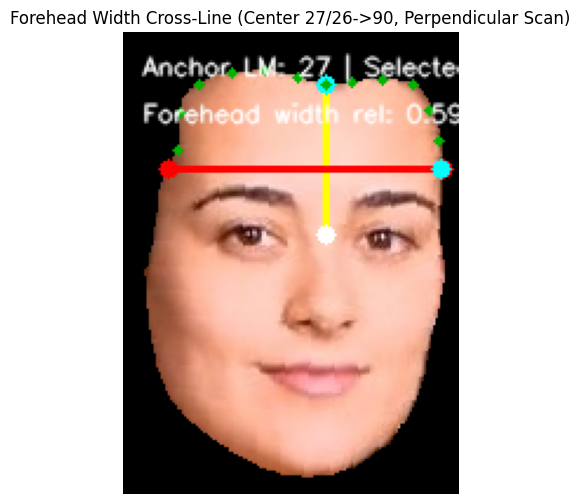

Forehead width (px): 117.00
Forehead width (rel): 0.594


In [28]:
# Debug + extraction standalone: acuan garis tetap dari titik tengah dahi (27/26) -> sudut 90
required_keys = ["parsing_mask", "landmarks", "angle_points"]
missing = [k for k in required_keys if k not in test_extraction]
if missing:
    raise ValueError(f"test_extraction belum lengkap, key hilang: {missing}")

parsing_mask = test_extraction["parsing_mask"]
landmarks = np.asarray(test_extraction["landmarks"], dtype=np.float32)
angle_points = test_extraction["angle_points"]

if 90 not in angle_points:
    raise ValueError("angle_points[90] tidak tersedia")

# Titik tengah dahi: prioritas landmark 27, fallback ke 26
if landmarks.shape[0] > 27:
    anchor_idx = 27
elif landmarks.shape[0] > 26:
    anchor_idx = 26
else:
    raise ValueError("Landmark 26/27 tidak tersedia")

p_anchor = np.array(landmarks[anchor_idx], dtype=np.float32)
p90 = np.array(angle_points[90], dtype=np.float32)

# Garis acuan utama: titik 27/26 -> sudut 90
center_dir = p90 - p_anchor
center_norm = float(np.linalg.norm(center_dir))
if center_norm < 1e-8:
    raise ValueError("Garis center (27/26->90) tidak valid")
center_dir /= center_norm
normal_dir = np.array([-center_dir[1], center_dir[0]], dtype=np.float32)

# Pakai face_masked berwarna sebagai background visualisasi (fallback ke parsing_mask)
vis_source = test_extraction.get("face_masked", None)
if vis_source is None:
    vis_source = parsing_mask

if vis_source.ndim == 2:
    vis = cv2.cvtColor(vis_source.astype(np.uint8), cv2.COLOR_GRAY2RGB)
elif vis_source.ndim == 3 and vis_source.shape[2] == 1:
    vis = cv2.cvtColor(vis_source[:, :, 0].astype(np.uint8), cv2.COLOR_GRAY2RGB)
else:
    vis = vis_source.copy().astype(np.uint8)

if vis.max() <= 1:
    vis = (vis * 255).astype(np.uint8)

# Mask biner untuk tracing garis
if parsing_mask.ndim == 2:
    mask_gray = parsing_mask
elif parsing_mask.ndim == 3 and parsing_mask.shape[2] == 1:
    mask_gray = parsing_mask[:, :, 0]
else:
    mask_gray = cv2.cvtColor(parsing_mask.astype(np.uint8), cv2.COLOR_RGB2GRAY)

mask_bin = (mask_gray > 0).astype(np.uint8)
h, w = mask_bin.shape
normalize_by = float(max(h, w))

max_steps = int(np.hypot(h, w))
def trace_last_inside(start_xy, dir_xy):
    last_inside = None
    for step in range(max_steps + 1):
        x = int(round(float(start_xy[0] + dir_xy[0] * step)))
        y = int(round(float(start_xy[1] + dir_xy[1] * step)))
        if x < 0 or x >= w or y < 0 or y >= h:
            break
        if mask_bin[y, x] > 0:
            last_inside = (x, y)
        elif step > 0 and last_inside is not None:
            break
    return last_inside

# Kandidat sudut dari area dahi atas: 20..160 (hindari 0/180)
candidate_raw = ANGLES_DENSE if "ANGLES_DENSE" in globals() else sorted(angle_points.keys())
start_angle = 30
end_angle = 150
candidate_angles = [int(a) for a in candidate_raw if (a in angle_points and start_angle <= int(a) <= end_angle)]
if not candidate_angles:
    candidate_angles = [int(a) for a in candidate_raw if a in angle_points]

best = {
    "width_px": -1.0,
    "selected_angle": None,
    "start_point": None,
    "end_point_a": None,
    "end_point_b": None,
}

# Untuk tiap sudut kandidat, tarik garis tegak lurus terhadap garis acuan center
for a in candidate_angles:
    start_pt = np.array(angle_points[a], dtype=np.float32)
    end_a = trace_last_inside(start_pt, normal_dir)
    end_b = trace_last_inside(start_pt, -normal_dir)
    if end_a is None or end_b is None:
        continue

    width_px = float(np.linalg.norm(np.array(end_a, dtype=np.float32) - np.array(end_b, dtype=np.float32)))
    if width_px > best["width_px"]:
        best["width_px"] = width_px
        best["selected_angle"] = int(a)
        best["start_point"] = tuple(map(int, start_pt))
        best["end_point_a"] = tuple(map(int, end_a))
        best["end_point_b"] = tuple(map(int, end_b))

if best["selected_angle"] is None:
    raise ValueError("Tidak menemukan forehead width line yang valid")

center_bottom = tuple(map(int, p_anchor))
center_top = tuple(map(int, p90))
forehead_width_px = float(best["width_px"])
forehead_width_rel = float(forehead_width_px / normalize_by)

line_info = {
    "center_top": center_top,
    "center_bottom": center_bottom,
    "start_point": best["start_point"],
    "end_point_a": best["end_point_a"],
    "end_point_b": best["end_point_b"],
    "selected_angle": best["selected_angle"],
    "candidate_angles": [int(x) for x in candidate_angles],
}

# Simpan hasil supaya bisa dipakai cell lain
test_extraction["forehead_width_line"] = line_info
test_extraction.setdefault("metrics", {})["forehead_width_rel"] = forehead_width_rel

# Draw garis acuan utama 27/26 -> 90
cv2.line(vis, line_info["center_bottom"], line_info["center_top"], (255, 255, 0), 2)
# Draw garis forehead width (tegak lurus garis acuan)
cv2.line(vis, line_info["end_point_a"], line_info["end_point_b"], (255, 0, 0), 2)

# Anchor points
cv2.circle(vis, line_info["center_bottom"], 4, (255, 255, 255), -1)
cv2.circle(vis, line_info["center_top"], 4, (0, 255, 255), -1)
cv2.circle(vis, line_info["start_point"], 4, (255, 255, 255), -1)
cv2.circle(vis, line_info["end_point_a"], 4, (255, 0, 0), -1)
cv2.circle(vis, line_info["end_point_b"], 4, (255, 0, 0), -1)

# Candidate angles marker
for a in line_info["candidate_angles"]:
    if a in angle_points:
        pt = tuple(map(int, angle_points[a]))
        color = (0, 255, 255) if a == line_info["selected_angle"] else (0, 180, 0)
        r = 4 if a == line_info["selected_angle"] else 2
        cv2.circle(vis, pt, r, color, -1)

label1 = f"Anchor LM: {anchor_idx} | Selected angle: {line_info['selected_angle']}"
label2 = f"Forehead width rel: {forehead_width_rel:.3f}"
cv2.putText(vis, label1, (8, 18), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (255, 255, 255), 1, cv2.LINE_AA)
cv2.putText(vis, label2, (8, 38), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (255, 255, 255), 1, cv2.LINE_AA)

plt.figure(figsize=(6, 6))
plt.imshow(vis)
plt.title("Forehead Width Cross-Line (Center 27/26->90, Perpendicular Scan)")
plt.axis("off")
plt.show()

print(f"Forehead width (px): {forehead_width_px:.2f}")
print(f"Forehead width (rel): {forehead_width_rel:.3f}")

### Heart Metrics
Not Used

In [29]:
## dahi_70 adalah jarak dari titik 27 ke titik angle 70 derajat, dihitung dalam pixel dan juga relatif terhadap max_dim.
p70 = test_extraction["angle_points"].get(70, None)
if p70 is not None:
    dahi_70_px = float(np.linalg.norm(np.array(p27) - np.array(p70)))
    dahi_70_rel = dahi_70_px / max_dim
    print(f"Dahi 70 (landmark 27 to angle 70): {dahi_70_rel:.3f} relative")

## dahi_110 adalah jarak dari titik 27 ke titik angle 110 derajat, dihitung dalam pixel dan juga relatif terhadap max_dim.
p110 = test_extraction["angle_points"].get(110, None)
if p110 is not None:
    dahi_110_px = float(np.linalg.norm(np.array(p27) - np.array(p110)))
    dahi_110_rel = dahi_110_px / max_dim
    print(f"Dahi 110 (landmark 27 to angle 110): {dahi_110_rel:.3f} relative")

## y_90_normalized adalah koordinat y dari titik angle 90 derajat relatif terhadap tinggi gambar (max_dim).
if 90 in test_extraction["angle_points"]:
    p90_y = test_extraction["angle_points"][90][1]
    y_90_normalized = p90_y / max_dim
    print(f"Y 90 normalized: {y_90_normalized:.3f}")

## y_max_normalized adalah koordinat y dari titik angle dengan nilai y terbesar di antara angle 70..110, relatif terhadap tinggi gambar (max_dim).
y_max_normalized = None
y_max_value = -1
y_max_angle = None
for a in range(70, 111, 10):
    if a in test_extraction["angle_points"]:
        y = test_extraction["angle_points"][a][1]
        print(y)
        if y > y_max_value:
            y_max_value = y
            y_max_angle = a
            y_max_normalized = y / max_dim
print(f"Y max normalized: {y_max_normalized:.3f}")
print(f"Y max angle: {y_max_angle} degrees")

Dahi 70 (landmark 27 to angle 70): 0.379 relative
Dahi 110 (landmark 27 to angle 110): 0.356 relative
Y 90 normalized: 0.112
16
19
22
21
20
Y max normalized: 0.112
Y max angle: 90 degrees


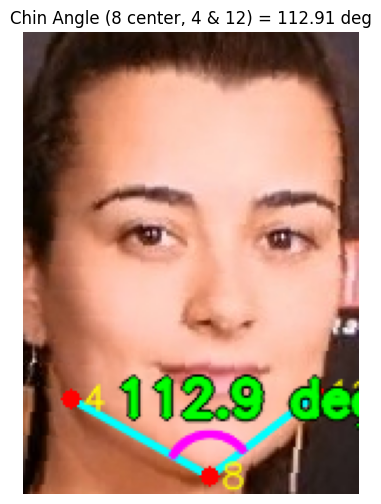

In [30]:
## Visualisasi Chin Angle pada contoh gambar
# Sudut dagu: landmark 8 sebagai titik tengah bawah, garis 8->4 dan 8->12,
# sudut yang terbuka ke atas/ke muka di antara kedua garis tersebut.

# Pakai aligned_face sebagai kanvas (landmark berada di koordinat aligned_face).
chin_vis = test_extraction["aligned_face"].copy()

p8 = tuple(map(int, test_extraction["landmarks"][8]))
p4 = tuple(map(int, test_extraction["landmarks"][4]))
p12 = tuple(map(int, test_extraction["landmarks"][12]))

# Hitung ulang sudut dagu (8->4 dan 8->12)
chin_vec_a = np.array(p4, dtype=np.float32) - np.array(p8, dtype=np.float32)
chin_vec_b = np.array(p12, dtype=np.float32) - np.array(p8, dtype=np.float32)
chin_angle_deg = np.degrees(
    np.arccos(
        np.clip(
            np.dot(chin_vec_a, chin_vec_b)
            / (np.linalg.norm(chin_vec_a) * np.linalg.norm(chin_vec_b) + 1e-8),
            -1.0,
            1.0,
        )
    )
)

# Garis dari titik tengah (8) ke 4 dan ke 12
cv2.line(chin_vis, p8, p4, (0, 255, 255), 2, cv2.LINE_AA)
cv2.line(chin_vis, p8, p12, (0, 255, 255), 2, cv2.LINE_AA)

# Arc untuk menandai sudut yang terbuka ke atas di titik 8
ang_a = np.degrees(np.arctan2(chin_vec_a[1], chin_vec_a[0]))
ang_b = np.degrees(np.arctan2(chin_vec_b[1], chin_vec_b[0]))
start_ang, end_ang = sorted([ang_a, ang_b])
arc_radius = int(0.18 * np.linalg.norm(np.array(p4) - np.array(p12)))
cv2.ellipse(chin_vis, p8, (arc_radius, arc_radius), 0, start_ang, end_ang, (255, 0, 255), 2, cv2.LINE_AA)

# Titik-titik landmark 4, 8, 12 + label
for pt, name in [(p4, "4"), (p8, "8"), (p12, "12")]:
    cv2.circle(chin_vis, pt, 4, (255, 0, 0), -1)
    cv2.putText(chin_vis, name, (pt[0] + 5, pt[1] + 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 1, cv2.LINE_AA)

# Tempel nilai derajat di dekat titik 8 (sedikit di atas)
label = f"{chin_angle_deg:.1f} deg"
cv2.putText(chin_vis, label, (p8[0] - 40, p8[1] - arc_radius - 8),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 4, cv2.LINE_AA)
cv2.putText(chin_vis, label, (p8[0] - 40, p8[1] - arc_radius - 8),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2, cv2.LINE_AA)

plt.figure(figsize=(6, 6))
plt.imshow(chin_vis)
plt.title(f"Chin Angle (8 center, 4 & 12) = {chin_angle_deg:.2f} deg")
plt.axis("off")
plt.show()
